In [1]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Titanic dataset

df = sns.load_dataset("titanic")

In [3]:
df.to_csv("titanic.csv", index=False)

print("dataset saved successfully!")

dataset saved successfully!


Dataset Profiling

In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 15)


Dataset Information

In [5]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Statistical Summary

In [6]:
print("Numerical Summary:")
df.describe()

Numerical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Complete Summary

In [7]:
print("Complete Summary:")
df.describe(include="all")

Complete Summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Values

In [8]:
# Calculate missing values

missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

missing_report = missing_report[
    missing_report["Missing Values"] > 0
]

missing_report.sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

,Missing Values,Missing Percentage (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


Missing Value Handling

In [9]:
# Display missing value report

missing_report

,Missing Values,Missing Percentage (%)
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


Perform Cleaning

In [10]:
# Drop rows where missing percentage is less than 5%

df.dropna(subset=["embarked", "embark_town"], inplace=True)

# Impute age using the median

df["age"] = df["age"].fillna(df["age"].median())

# Drop the deck column

df.drop(columns=["deck"], inplace=True)

Verify Cleaning

In [11]:
# Check for remaining missing values

remaining_missing = (
    df.isnull().sum()
      .to_frame("Missing Values")
)

remaining_missing[
    remaining_missing["Missing Values"] > 0
]

,Missing Values


Cleaned Dataset

In [12]:
# Save the cleaned dataset

df.to_csv("titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Histogram of Age


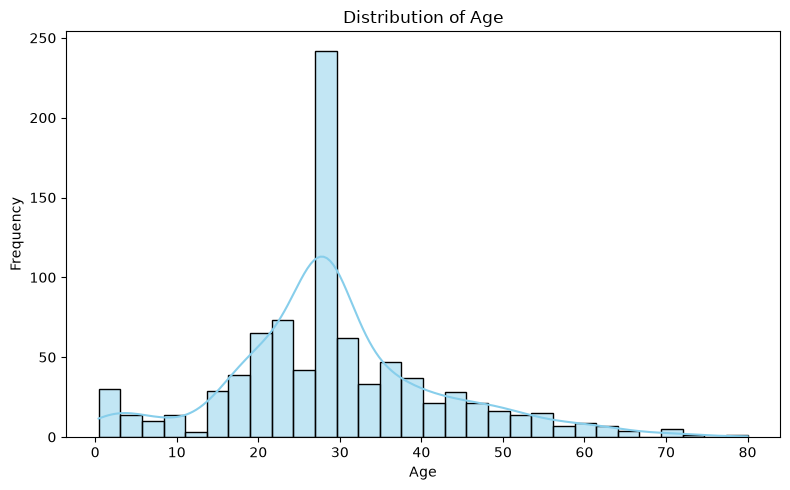

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("figures/age_histogram.png", dpi=300)

plt.show()

In [14]:
from pathlib import Path

# Create figures directory if it doesn't exist
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [15]:
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

Age Box Plot


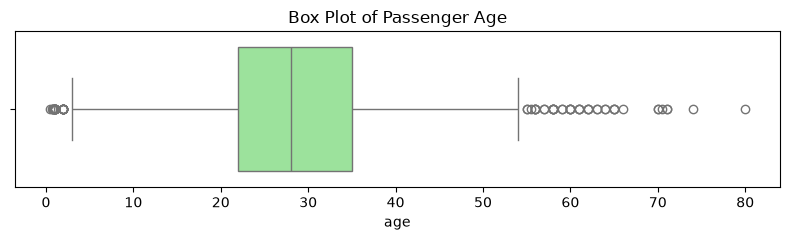

In [16]:
plt.figure(figsize=(8,2.5))

sns.boxplot(
    x=df["age"],
    color="lightgreen"
)

plt.title("Box Plot of Passenger Age")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Distribution of Fare

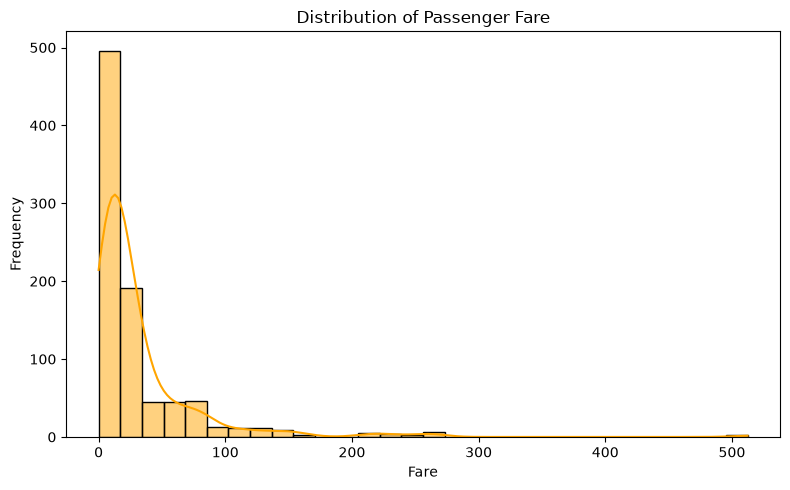

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fare_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Box Plot of Fare

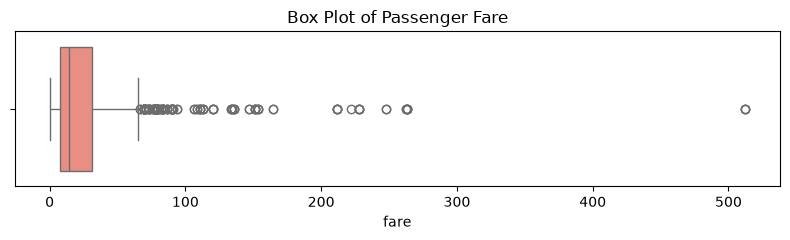

In [18]:
plt.figure(figsize=(8,2.5))

sns.boxplot(
    x=df["fare"],
    color="salmon"
)

plt.title("Box Plot of Passenger Fare")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fare_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Count IQR Outliers

In [19]:
# Function to count outliers using the IQR rule

def count_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)

    outliers = series[(series < lower) | (series > upper)]

    return len(outliers)

Report Outliers

In [20]:
age_outliers = count_outliers(df["age"])
fare_outliers = count_outliers(df["fare"])

print(f"Number of Age Outliers  : {age_outliers}")
print(f"Number of Fare Outliers : {fare_outliers}")

Number of Age Outliers  : 65
Number of Fare Outliers : 114


Mean, Median and Mode

In [21]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"Mean   : {fare_mean:.2f}")
print(f"Median : {fare_median:.2f}")
print(f"Mode   : {fare_mode:.2f}")

Mean   : 32.10
Median : 14.45
Mode   : 8.05


Determine Skewness

In [22]:
if fare_mean > fare_median > fare_mode:
    skewness = "Right-Skewed"
elif fare_mean < fare_median < fare_mode:
    skewness = "Left-Skewed"
else:
    skewness = "Approximately Symmetric"

print("Fare Distribution:", skewness)

Fare Distribution: Right-Skewed


Boolean Masking

In [23]:
# Boolean Masking Examples

female_passengers = df[df["sex"] == "female"]

male_passengers = df[df["sex"] == "male"]

first_class_female = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

male_or_second_class = df[
    (df["sex"] == "male") |
    (df["pclass"] == 2)
]

print(f"Female Passengers: {len(female_passengers)}")
print(f"Male Passengers: {len(male_passengers)}")
print(f"First Class Female Passengers: {len(first_class_female)}")
print(f"Male OR Second Class Passengers: {len(male_or_second_class)}")

Female Passengers: 312
Male Passengers: 577
First Class Female Passengers: 92
Male OR Second Class Passengers: 653


Survival Rate by Gender

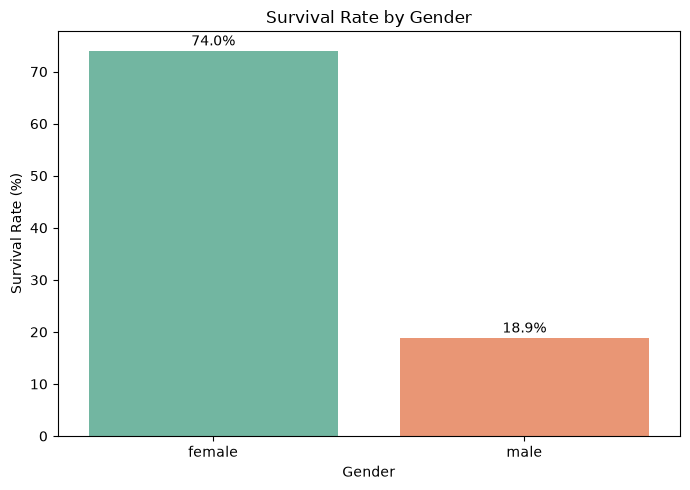

sex
female    74.04
male      18.89
Name: survived, dtype: float64


In [24]:
# Survival Rate by Gender

survival_gender = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=survival_gender.index,
    y=survival_gender.values,
    hue=survival_gender.index,
    palette="Set2",
    legend=False
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

for i, value in enumerate(survival_gender.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(survival_gender)

Survival Rate by Passenger Class

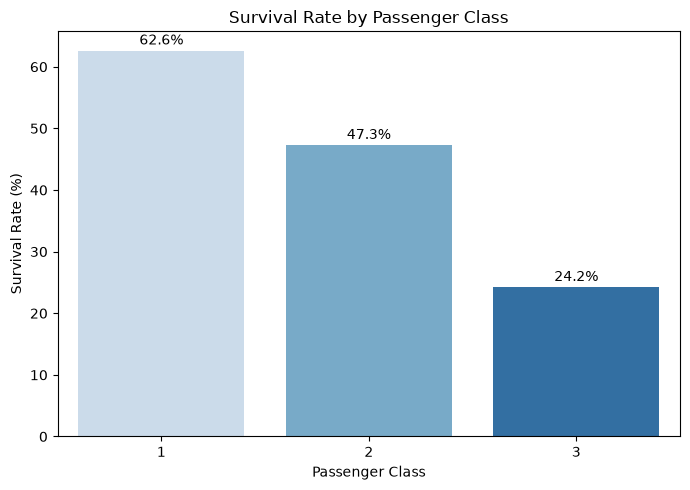

pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64


In [25]:
# Survival Rate by Passenger Class

survival_pclass = (
    df.groupby("pclass")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=survival_pclass.index.astype(str),
    y=survival_pclass.values,
    hue=survival_pclass.index.astype(str),
    palette="Blues",
    legend=False
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

for i, value in enumerate(survival_pclass.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_pclass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(survival_pclass)

Survival Rate by Gender and Passenger Class

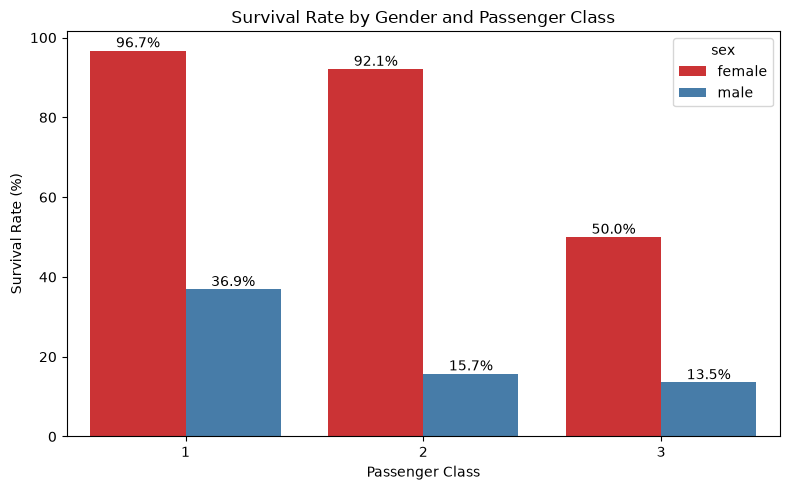

   pclass     sex  survived
0       1  female     96.74
1       1    male     36.89
2       2  female     92.11
3       2    male     15.74
4       3  female     50.00
5       3    male     13.54


In [26]:
# Survival Rate by Gender and Passenger Class

survival_gender_class = (
    df.groupby(["pclass", "sex"])["survived"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=survival_gender_class,
    x="pclass",
    y="survived",
    hue="sex",
    palette="Set1"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "survival_by_gender_pclass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(survival_gender_class)

Correlation Matrix

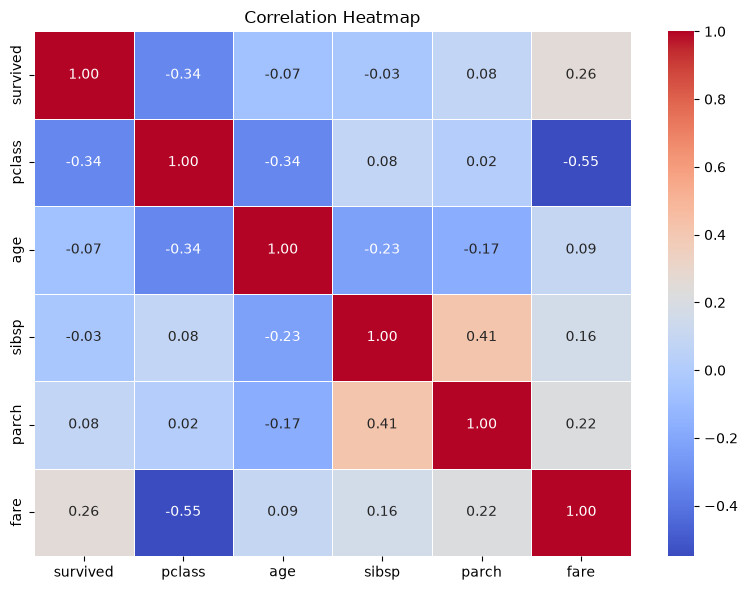

In [27]:
# Correlation matrix using the required columns

corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Find the two strongest correlations

corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Top Two Strongest Correlations:")
print(corr_pairs.head(2))

Top Two Strongest Correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


Multivariate Data Story

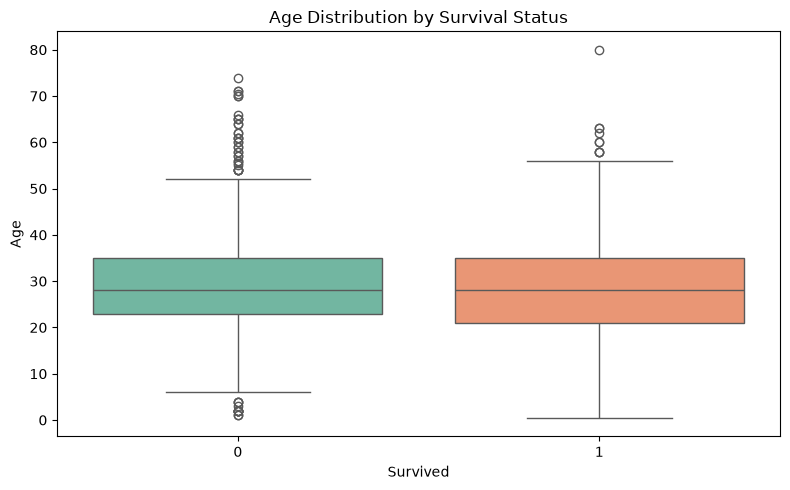

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="survived",
    y="age",
    hue="survived",
    palette="Set2",
    legend=False
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "age_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The box plot shows that passengers who survived generally tended to be younger than those who did not survive, although there is considerable overlap between the two groups. Children appear more frequently among the survivors, supporting the historical evacuation policy of prioritizing women and children. Age influenced survival, but it was not the only determining factor.

Fare Distribution by Survival

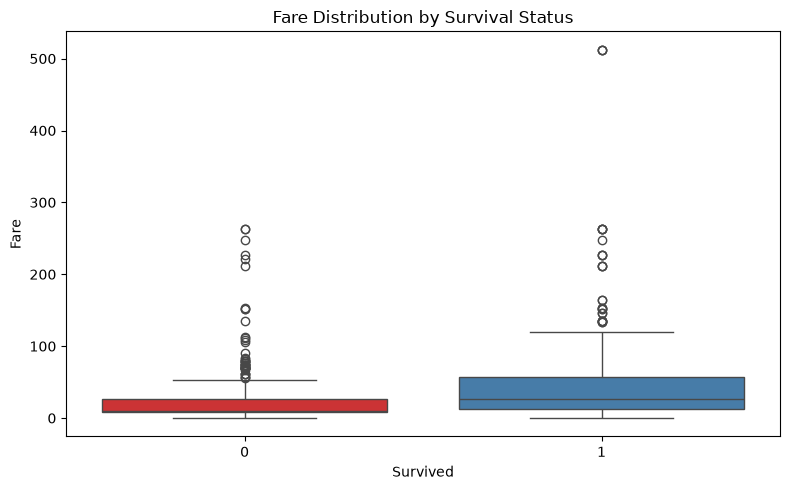

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare",
    hue="survived",
    palette="Set1",
    legend=False
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fare_vs_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Passengers who paid higher fares generally had a higher probability of surviving. This is because higher fares are strongly associated with first-class travel, where passengers had better access to lifeboats and assistance during evacuation. The distribution also contains several high-fare outliers, indicating premium-class passengers.

Survival by Embarkation Port

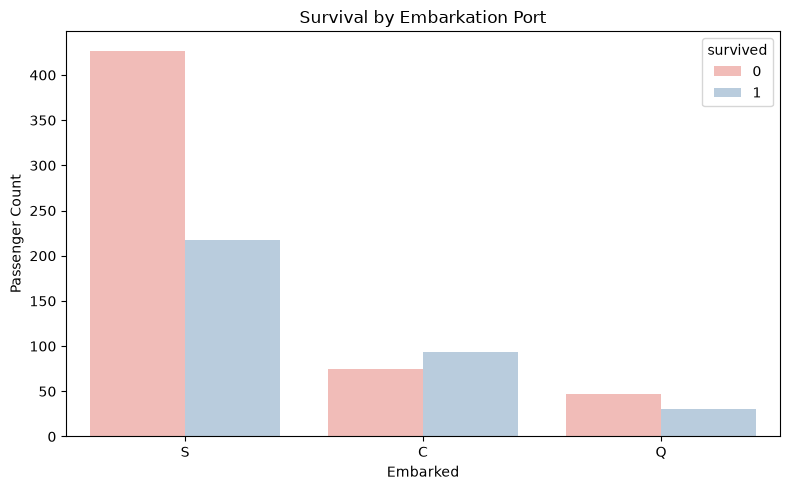

In [31]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="embarked",
    hue="survived",
    palette="Pastel1"
)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Passenger Count")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "embarked_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Survival rates differ across embarkation ports. Passengers embarking from Cherbourg show a higher proportion of survivors compared to Southampton and Queenstown, largely because a greater number of first-class passengers boarded there. This suggests that embarkation location indirectly reflects passenger demographics and socioeconomic status.

Pair Plot


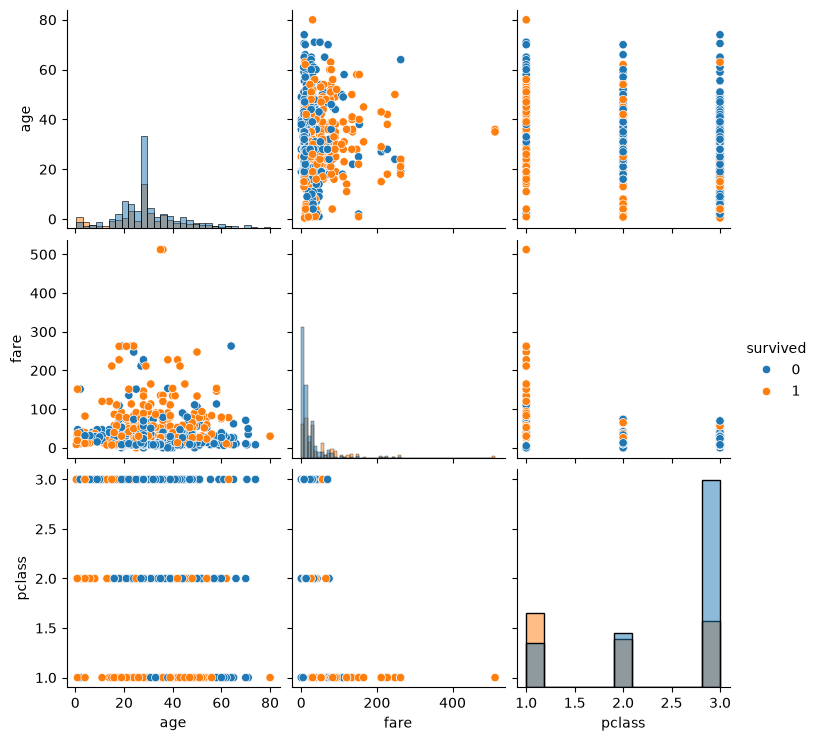

In [32]:
pairplot = sns.pairplot(
    df[
        ["survived", "age", "fare", "pclass"]
    ],
    hue="survived",
    diag_kind="hist"
)

pairplot.savefig(
    FIGURES_DIR / "pairplot.png",
    dpi=300
)

plt.show()

### Interpretation

The pair plot provides an overview of relationships among the selected numerical variables. Fare and passenger class exhibit a noticeable relationship, while the separation between survivors and non-survivors is more evident for fare than for age. Overall, fare and passenger class appear to be stronger predictors of survival than age alone.

Standardization Check (Z-Score)

In [33]:
# Summary statistics before standardization

print("Before Standardization")

df[["age", "fare"]].agg(["mean", "std"])

Before Standardization


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["age_z", "fare_z"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

In [36]:
print("After Standardization")

df[["age_z", "fare_z"]].agg(["mean", "std"])

After Standardization


,age_z,fare_z
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
